# Design 5: baseline study with Algorithm A4

From `literature-notes/main-project-idea.txt`: "another baseline study that is identical to Design 4, but using Algorithm A4." Algorithm A4 is identical to A3 except `r = gamma * time_averaged_aesthetic_basis` instead of the running average directly -- `gamma` is a free tolerance/sensitivity knob on the inverted-U's width (the left-anchored parabola's peak sits at `r/2`, right root at `r`, so `gamma>1` widens the range of surprise that still scores positively, `gamma<1` narrows it). Confirmed with Mark: `gamma` defaults to 1.0 (which reduces Algorithm A4 exactly to Algorithm A3 -- verified: with `noise=0`, `run_design5(gamma=1.0)` matches `run_design4` exactly) and is meant to be explored, not a single fixed value.

Same random ergodic environment as Design 1/4 (not Design 2/3's cyclic one), same `{song_id, evaluation}` chunk schema, same two goals: (1) how `evaluation` varies over time, (2) how `time_averaged_aesthetic_basis` varies over time.

Same quadratic-ish scaling as Designs 3/4 (chunk count grows with trial count), so this defaults to `NUM_EXPOSURES=2000`.

Change `GAMMA` (and the other parameters) below and re-run to explore. Note: `seed` only controls song-sequence sampling, not pyactup's own internal noise RNG -- set `NOISE=0` for a fully deterministic, reproducible run.

In [10]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_design5

NUM_SONGS = 10
NUM_EXPOSURES = 200
WINDOW = 20                       # post-hoc rolling-mean window, for plotting evaluation
SEED = 42
NOISE = 0.25                      # set to 0 for a deterministic run
DECAY = 0.5

GAMMA = 2.0                       # r = GAMMA * time_averaged_aesthetic_basis; 1.0 == Algorithm A3
TIME_AVERAGE_MODE = "window"
TIME_AVERAGE_WINDOW = 20          # only used when TIME_AVERAGE_MODE == "window" vs "cumulative"

ANNOTATE_SONGS = False
ANNOTATE_MAX_LABELS = 15

## Run

In [11]:
df = run_design5(num_songs=NUM_SONGS, num_exposures=NUM_EXPOSURES, window=WINDOW,
                  seed=SEED, noise=NOISE, decay=DECAY, gamma=GAMMA,
                  time_average_mode=TIME_AVERAGE_MODE, time_average_window=TIME_AVERAGE_WINDOW,
                  config_path="../config.yaml",
                  output_path="../results/data/design5_baseline_a4_timeseries.csv")
df.describe()

,predicted_activation,actual_activation,aesthetic_basis,time_averaged_aesthetic_basis,gamma,r,evaluation,trial,complexity,evaluation_rolling_mean
count,190.000000,190.000000,190.000000,190.000000,190.0,190.000000,190.000000,190.000000,190.000000,171.000000
mean,0.234706,-0.774685,1.052075,1.055256,2.0,2.110513,0.736060,104.257895,3.894737,0.737071
std,0.349326,0.511982,0.566313,0.120436,0.0,0.240871,0.319254,55.382764,2.738994,0.071231
min,-0.440748,-2.132505,0.011022,0.459923,2.0,0.919846,-0.708590,4.000000,1.000000,0.596478
25%,-0.004233,-1.122779,0.628718,0.981840,2.0,1.963679,0.590098,57.250000,2.000000,0.684765
50%,0.213367,-0.838214,1.006760,1.046436,2.0,2.092873,0.857157,104.500000,3.000000,0.719989
75%,0.421444,-0.464474,1.411929,1.111787,2.0,2.223575,0.962501,151.750000,4.000000,0.803283
max,1.423550,1.136997,3.101205,1.344183,2.0,2.688366,1.000000,199.000000,10.000000,0.887146


## Goal 1: evaluation over time

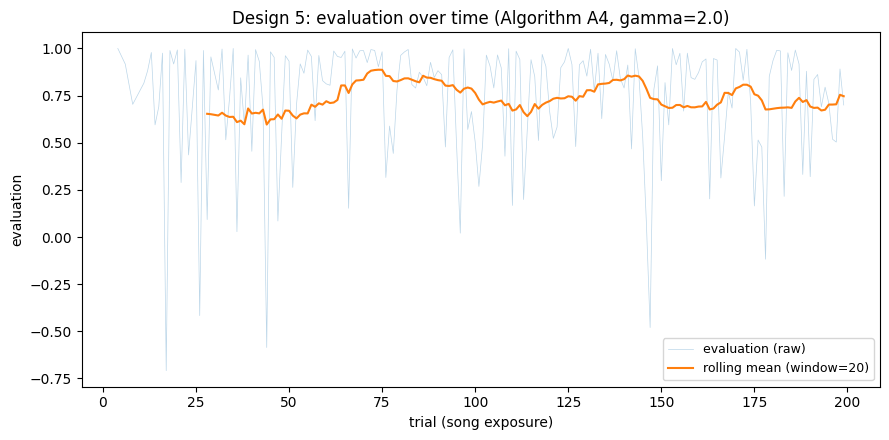

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["trial"], df["evaluation"], alpha=0.3, linewidth=0.5,
        color="tab:blue", label="evaluation (raw)")
ax.plot(df["trial"], df["evaluation_rolling_mean"], linewidth=1.5,
        color="tab:orange", label=f"rolling mean (window={WINDOW})")

if ANNOTATE_SONGS:
    step = max(1, len(df) // ANNOTATE_MAX_LABELS)
    for _, row in df.iloc[::step].iterrows():
        ax.annotate(row["actual_song_id"], (row["trial"], row["evaluation"]),
                    fontsize=7, rotation=90, textcoords="offset points", xytext=(0, 5))

ax.set_xlabel("trial (song exposure)")
ax.set_ylabel("evaluation")
ax.set_title(f"Design 5: evaluation over time (Algorithm A4, gamma={GAMMA})")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("../results/figures/design5_evaluation_timeseries.png", dpi=150)

## Goal 2: time_averaged_aesthetic_basis over time

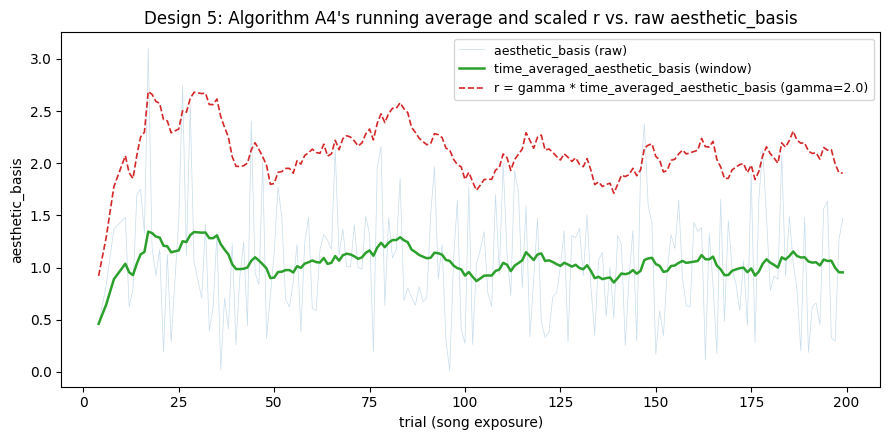

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["trial"], df["aesthetic_basis"], alpha=0.25, linewidth=0.5,
        color="tab:blue", label="aesthetic_basis (raw)")
ax.plot(df["trial"], df["time_averaged_aesthetic_basis"], linewidth=1.8,
        color="tab:green", label=f"time_averaged_aesthetic_basis ({TIME_AVERAGE_MODE})")
ax.plot(df["trial"], df["r"], linewidth=1.2, linestyle="--",
        color="tab:red", label=f"r = gamma * time_averaged_aesthetic_basis (gamma={GAMMA})")
ax.set_xlabel("trial (song exposure)")
ax.set_ylabel("aesthetic_basis")
ax.set_title("Design 5: Algorithm A4's running average and scaled r vs. raw aesthetic_basis")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("../results/figures/design5_time_averaged_basis.png", dpi=150)

The red dashed `r` line is what actually feeds the parabola each trial -- it's `time_averaged_aesthetic_basis` scaled by `gamma`, so at `GAMMA=1.0` it sits exactly on top of the green line (Design 4/Algorithm A3's behavior); moving `GAMMA` away from 1 separates the two lines and reshapes how forgiving/strict the evaluation is relative to Design 4's baseline.